# 02. Exploratory Data Analysis (EDA)

In this notebook, we will explore the cleaned A/B testing dataset to understand user behavior, visualize key metrics, and uncover potential patterns before conducting formal statistical tests. 

Objectives:
1. Conversion Rate Analysis: Compare overall conversion rates and rates between the control and treatment groups.
2. Revenue Analysis: Examine the distribution of purchase amounts and compare average revenue per user.
3. Device Analysis: Understand user distribution across devices and how device type impacts conversion.
4. Demographic Analysis: Explore age and gender distributions.
5. Engagement Metrics: Analyze session duration and pages visited across the two groups.

In [6]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic parameters for visualizations
sns.set_theme(style='whitegrid', palette='muted')

import warnings
warnings.filterwarnings('ignore')

### Load Cleaned Dataset

In [7]:
# Load the dataset
df = pd.read_csv('../data/processed/cleaned_data.csv')

# Display the first few rows to confirm it loaded correctly
df.head()

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0


--- 
### 1. Conversion Rate Analysis

First, we will look at the overall conversion rate, and then compare the conversion rate between our control (old page) and treatment (new page) groups.

Overall Conversion Rate: 14.92%
Conversion Rate by Group:
group
control      11.872643
treatment    17.948926
Name: converted, dtype: float64


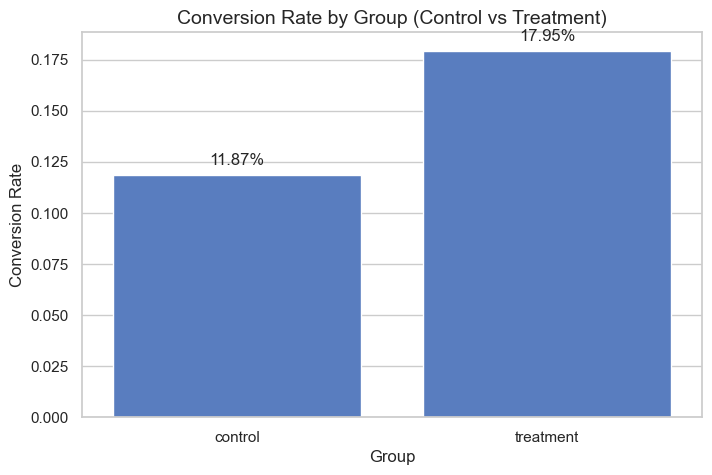

In [12]:
# Calculate overall conversion rate
overall_cr = df['converted'].mean() * 100
print(f'Overall Conversion Rate: {overall_cr:.2f}%')

# Calculate conversion rate by group
group_cr = df.groupby('group')['converted'].mean() * 100
print('Conversion Rate by Group:')
print(group_cr)

# Visualize Conversion Rate by Group
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='group', y='converted', data=df, errorbar=None)
plt.title('Conversion Rate by Group (Control vs Treatment)', fontsize=14)
plt.ylabel('Conversion Rate', fontsize=12)
plt.xlabel('Group', fontsize=12)

# Annotate bars with percentages
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

--- 
### 2. Revenue Analysis

Next, we evaluate the purchase_amount. Since many users likely did not convert (purchase amount = 0), we will look at the average revenue per user (ARPU) across the groups, and the distribution of non-zero purchases.

Average Revenue Per User (ARPU):
group
control      4.452769
treatment    6.763299
Name: purchase_amount, dtype: float64


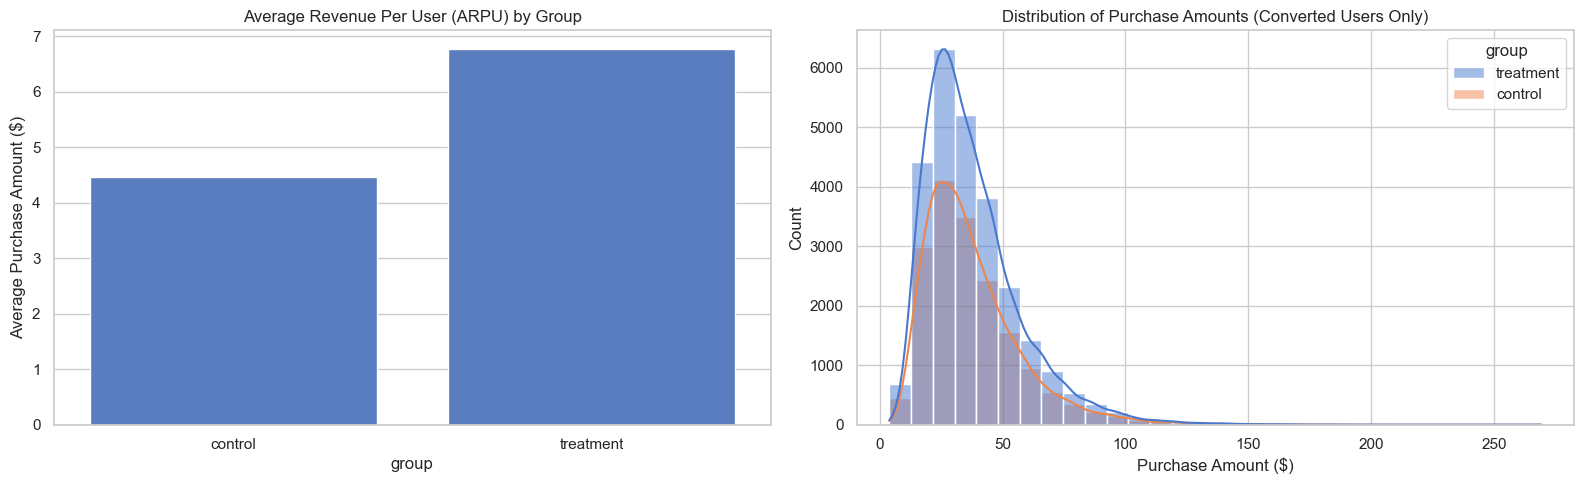

In [13]:
# Average Revenue per User (ARPU) by group
arpu = df.groupby('group')['purchase_amount'].mean()
print('Average Revenue Per User (ARPU):')
print(arpu)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Average Purchase Amount by Group (including 0s)
sns.barplot(x='group', y='purchase_amount', data=df, ax=axes[0], errorbar=None)
axes[0].set_title('Average Revenue Per User (ARPU) by Group')
axes[0].set_ylabel('Average Purchase Amount ($)')

# Plot 2: Distribution of Purchase Amounts for Paying Customers Only
paying_users = df[df['purchase_amount'] > 0]
sns.histplot(data=paying_users, x='purchase_amount', hue='group', kde=True, ax=axes[1], bins=30)
axes[1].set_title('Distribution of Purchase Amounts (Converted Users Only)')
axes[1].set_xlabel('Purchase Amount ($)')

plt.tight_layout()
plt.show()

---
### 3. Device Analysis

It is crucial to understand if the landing page performs differently across devices. We will visualize the distribution of users by device type and calculate the conversion rate for each.

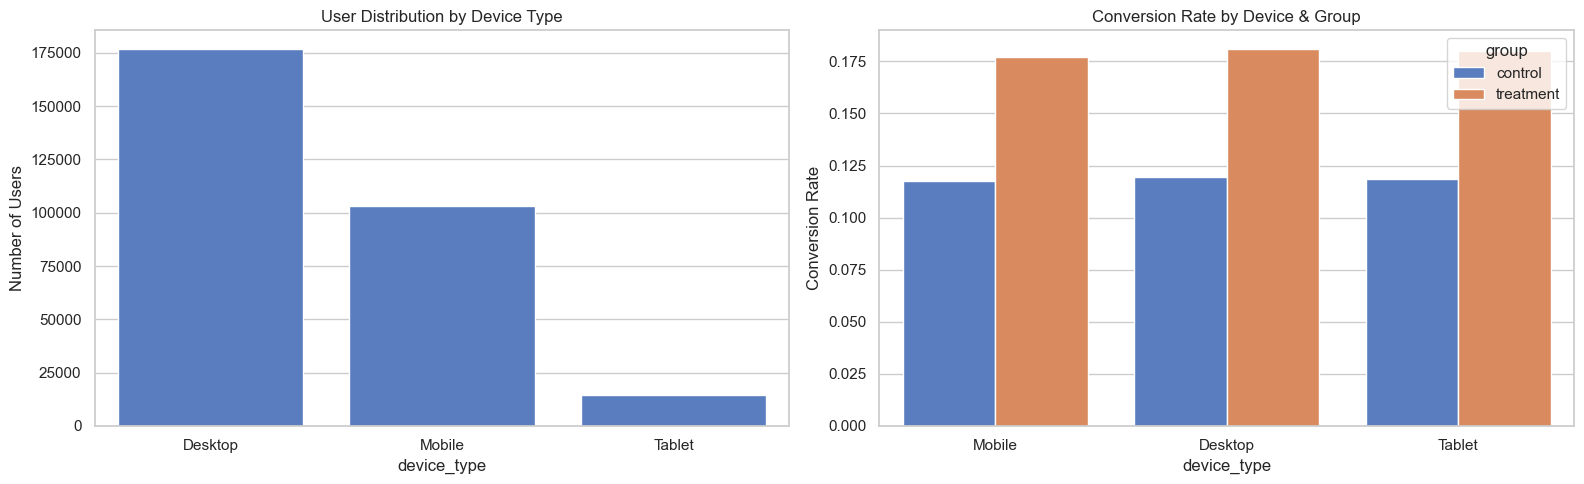

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: User Distribution by Device
sns.countplot(x='device_type', data=df, ax=axes[0], order=df['device_type'].value_counts().index)
axes[0].set_title('User Distribution by Device Type')
axes[0].set_ylabel('Number of Users')

# Plot 2: Conversion Rate by Device and Group
sns.barplot(x='device_type', y='converted', hue='group', data=df, ax=axes[1], errorbar=None)
axes[1].set_title('Conversion Rate by Device & Group')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

---
### 4. Demographic Analysis

Understanding our user base's demographics ensures our traffic was split evenly and helps identify primary user segments.

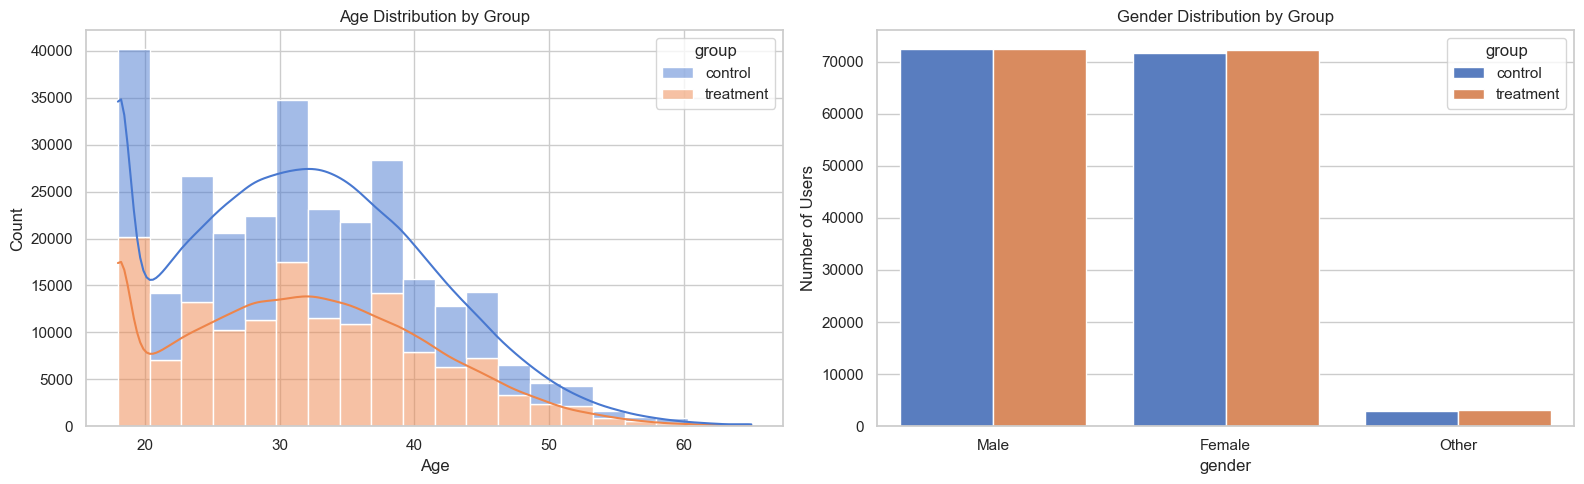

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Age Distribution
sns.histplot(data=df, x='age', hue='group', bins=20, kde=True, ax=axes[0], multiple='stack')
axes[0].set_title('Age Distribution by Group')
axes[0].set_xlabel('Age')

# Plot 2: Gender Distribution
sns.countplot(x='gender', hue='group', data=df, ax=axes[1])
axes[1].set_title('Gender Distribution by Group')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

---
### 5. Engagement Metrics

Finally, we assess if the new page keeps users more engaged by analyzing session_duration and the number of pages_visited.

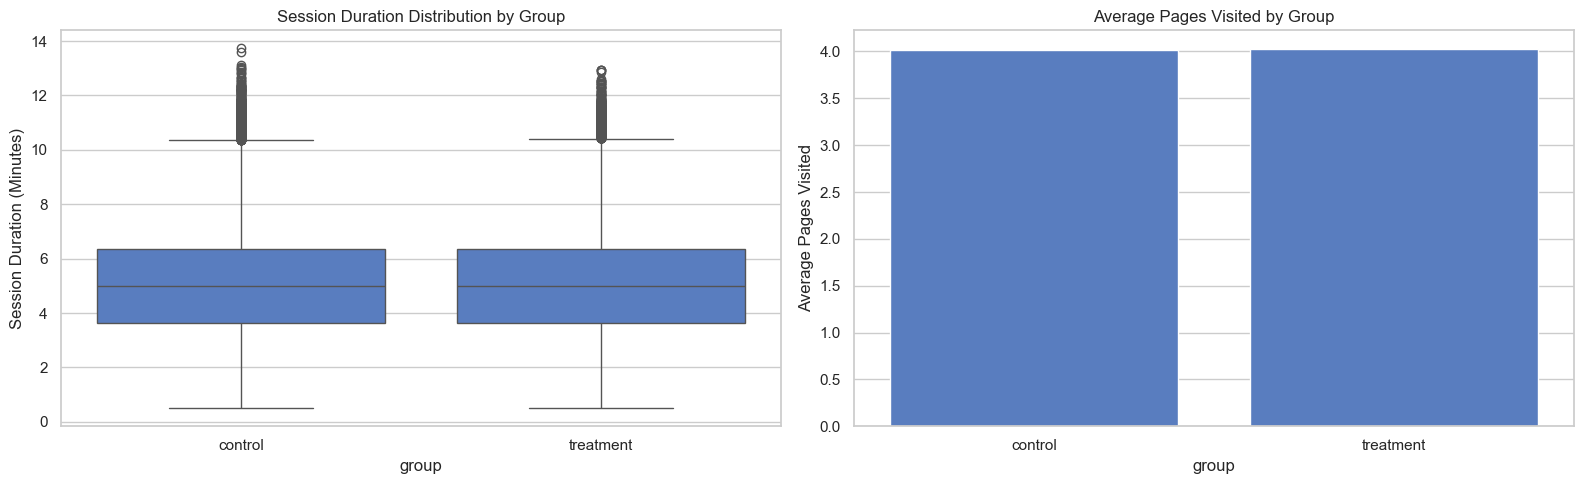

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Session Duration Boxplot
sns.boxplot(x='group', y='session_duration', data=df, ax=axes[0])
axes[0].set_title('Session Duration Distribution by Group')
axes[0].set_ylabel('Session Duration (Minutes)')

# Plot 2: Pages Visited
sns.barplot(x='group', y='pages_visited', data=df, ax=axes[1], errorbar=None)
axes[1].set_title('Average Pages Visited by Group')
axes[1].set_ylabel('Average Pages Visited')

plt.tight_layout()
plt.show()

## Exporting of experiment_summary.csv

In [17]:
# Add this cell to the end of the notebook to export summary CSVs

import os

os.makedirs('../data/processed', exist_ok=True)

# --- 1. Overall Experiment Summary ---
overall_cr = df['converted'].mean() * 100
group_cr = df.groupby('group')['converted'].mean() * 100
arpu = df.groupby('group')['purchase_amount'].mean()
avg_session = df.groupby('group')['session_duration'].mean()
avg_pages = df.groupby('group')['pages_visited'].mean()
group_counts = df.groupby('group').size()

experiment_summary = pd.DataFrame({
    'group': group_cr.index,
    'users': group_counts.values,
    'conversion_rate_pct': group_cr.values,
    'arpu': arpu.reindex(group_cr.index).values,
    'avg_session_duration': avg_session.reindex(group_cr.index).values,
    'avg_pages_visited': avg_pages.reindex(group_cr.index).values,
})

experiment_summary.loc[len(experiment_summary)] = {
    'group': 'overall',
    'users': len(df),
    'conversion_rate_pct': overall_cr,
    'arpu': df['purchase_amount'].mean(),
    'avg_session_duration': df['session_duration'].mean(),
    'avg_pages_visited': df['pages_visited'].mean(),
}

experiment_summary.to_csv('../data/processed/experiment_summary.csv', index=False)
print("Saved experiment_summary.csv")
experiment_summary

Saved experiment_summary.csv


,group,users,conversion_rate_pct,arpu,avg_session_duration,avg_pages_visited
0,control,146926,11.872643,4.452769,5.003684,4.015327
1,treatment,147552,17.948926,6.763299,5.000594,4.023754
2,overall,294478,14.917243,5.610490,5.002136,4.019550


## Exporting of segment_summary.csv

In [18]:
# --- 2. Segment Summary (device, gender, location breakdowns by group) ---

segment_frames = []

for seg_col in ['device_type', 'gender', 'location']:
    seg = df.groupby([seg_col, 'group']).agg(
        users=('user_id', 'count'),
        conversion_rate_pct=('converted', lambda x: x.mean() * 100),
        arpu=('purchase_amount', 'mean'),
        avg_session_duration=('session_duration', 'mean'),
        avg_pages_visited=('pages_visited', 'mean'),
    ).reset_index()
    seg.insert(0, 'segment_type', seg_col)
    seg = seg.rename(columns={seg_col: 'segment_value'})
    segment_frames.append(seg)

segment_summary = pd.concat(segment_frames, ignore_index=True)
segment_summary.to_csv('../data/processed/segment_summary.csv', index=False)
print("Saved segment_summary.csv")
segment_summary.head(20)

Saved segment_summary.csv


,segment_type,segment_value,group,users,conversion_rate_pct,arpu,avg_session_duration,avg_pages_visited
0,device_type,Desktop,control,88397,11.949501,4.473342,5.001789,4.010509
1,device_type,Desktop,treatment,88295,18.082564,6.795546,4.998111,4.030579
2,device_type,Mobile,control,51177,11.743557,4.423872,5.005912,4.022530
3,device_type,Mobile,treatment,51916,17.713229,6.706030,5.002158,4.009284
4,device_type,Tablet,control,7352,11.847116,4.406561,5.010958,4.023123
5,device_type,Tablet,treatment,7341,18.008446,6.780460,5.019407,4.043999
6,gender,Female,control,71623,11.825810,4.446378,4.999574,4.011435
7,gender,Female,treatment,72162,17.843186,6.741496,4.997692,4.031845
8,gender,Male,control,72348,11.886991,4.454235,5.010103,4.020761
9,gender,Male,treatment,72360,18.056938,6.778244,5.004327,4.016017
